<a href="https://colab.research.google.com/github/trantuyen04072007/ueh-map/blob/main/Ch%C3%A0o_m%E1%BB%ABng_b%E1%BA%A1n_%C4%91%E1%BA%BFn_v%E1%BB%9Bi_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_dir = "/content/drive/MyDrive/Ảnh Lớp IC"
img_width, img_height = 280, 280
batch_size = 32
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)
num_classes = train_generator.num_classes
print(class_indices := train_generator.class_indices)

Found 1289 images belonging to 34 classes.
Found 317 images belonging to 34 classes.
{' Quang Minh': 0, 'Anh Kiệt ': 1, 'BÙI VÕ THUẬT': 2, 'Công Minh': 3, 'Gia Nghia': 4, 'Hoàng Hiệp': 5, 'Hữu Tài': 6, 'Hữu Đại ': 7, 'Khánh Thi': 8, 'Lê Nhân': 9, 'Long Nhật': 10, 'Mai Hữu Phúc': 11, 'Minh Thiên': 12, 'Minh Thư': 13, 'Minh Tiến': 14, 'Mỹ Ngân': 15, 'Ngọc Huy': 16, 'Nguyễn Huy Hoàng': 17, 'Nhật Anh': 18, 'Phát Thịnh': 19, 'Quang Dũng': 20, 'Quang Huy': 21, 'Quang Nhật': 22, 'Song Phát': 23, 'Thiên Ân': 24, 'Trọng Duy': 25, 'Trọng Phước': 26, 'VanTuyen': 27, 'Văn Hoàng': 28, 'Võ Duy Khang': 29, 'Võ Phạm Duy Khang': 30, 'Võ Quốc Khánh': 31, 'Võ Thiên Bảo': 32, 'Đắc Minh': 33}


In [5]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 278, 278, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 139, 139, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 137, 137, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 68, 68, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 66, 66, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 33, 33, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 139392)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    71,369,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 34)             │        17,442 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,479,906 (272.67 MB)

 Trainable params: 71,479,906 (272.67 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
epochs = 10

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    epochs=epochs
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.4988 - loss: 1.6549 - val_accuracy: 0.5903 - val_loss: 1.4564
Epoch 2/10
 1/40 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step - accuracy: 0.4375 - loss: 1.7093

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


40/40 ━━━━━━━━━━━━━━━━━━━━ 13s 337ms/step - accuracy: 0.4375 - loss: 1.7093 - val_accuracy: 0.5417 - val_loss: 1.5010
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.5609 - loss: 1.3599 - val_accuracy: 0.7083 - val_loss: 1.0812
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 360ms/step - accuracy: 0.6250 - loss: 1.2584 - val_accuracy: 0.7535 - val_loss: 1.0256
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.6492 - loss: 1.1392 - val_accuracy: 0.6701 - val_loss: 1.1621
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 363ms/step - accuracy: 0.5556 - loss: 1.0717 - val_accuracy: 0.6528 - val_loss: 1.2100
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.6850 - loss: 1.0015 - val_accuracy: 0.7917 - val_loss: 0.7946
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 14s 368ms/step - accuracy: 0.5938 - loss: 1.3315 - val_accuracy: 0.7951 - val_loss: 0.7464
Epoch 9/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.7621 - loss: 0.7988 - val_accuracy: 0.8229 - val_loss

AI đã sẵn sàng nhận diện các lớp sau: [' Quang Minh', 'Anh Kiệt ', 'BÙI VÕ THUẬT', 'Công Minh', 'Gia Nghia', 'Hoàng Hiệp', 'Hữu Tài', 'Hữu Đại ', 'Khánh Thi', 'Lê Nhân', 'Long Nhật', 'Mai Hữu Phúc', 'Minh Thiên', 'Minh Thư', 'Minh Tiến', 'Mỹ Ngân', 'Ngọc Huy', 'Nguyễn Huy Hoàng', 'Nhật Anh', 'Phát Thịnh', 'Quang Dũng', 'Quang Huy', 'Quang Nhật', 'Song Phát', 'Thiên Ân', 'Trọng Duy', 'Trọng Phước', 'VanTuyen', 'Văn Hoàng', 'Võ Duy Khang', 'Võ Phạm Duy Khang', 'Võ Quốc Khánh', 'Võ Thiên Bảo', 'Đắc Minh']
--------------------------------------------------


Saving WIN_20260528_20_55_30_Pro.jpg to WIN_20260528_20_55_30_Pro.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


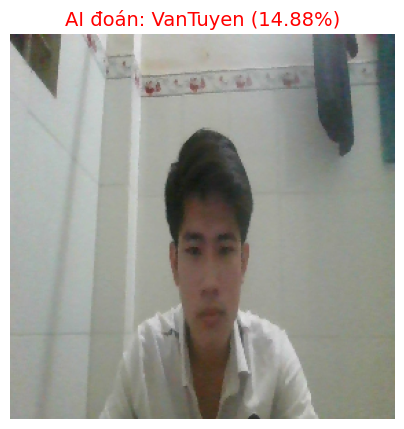

Chi tiết: File 'WIN_20260528_20_55_30_Pro.jpg' được dự đoán là [VanTuyen] với độ tự tin 14.88%


In [34]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from google.colab import files
class_indices = train_generator.class_indices
labels = {v: k for k, v in class_indices.items()}
print("AI đã sẵn sàng nhận diện các lớp sau:", list(labels.values()))
print("-" * 50)
uploaded = files.upload()
for filename in uploaded.keys():
    img_path = filename
    img = image.load_img(img_path, target_size=(img_width, img_height))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0
    predictions = model.predict(img_array)
    score = np.max(predictions)
    predicted_class = np.argmax(predictions)
    name_predicted = labels[predicted_class]
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"AI đoán: {name_predicted} ({score*100:.2f}%)", fontsize=14, color='green' if score > 0.6 else 'red')
    plt.show()
    print(f"Chi tiết: File '{filename}' được dự đoán là [{name_predicted}] với độ tự tin {score*100:.2f}%")